# Spam Email Detection Using Machine Learning
### Machine Learning Lab Mini Project
**Objective:** Build, train, compare, evaluate, and deploy an end-to-end Machine Learning pipeline to accurately classify incoming emails and messages as **SPAM** or **HAM (Not Spam)** using Natural Language Processing (NLP), **TF-IDF Feature Extraction**, and **Multinomial Naive Bayes** (alongside Logistic Regression and SVM comparisons).

---
### Workflow Architecture:
1. **Dataset Loading & Exploration**
2. **Exploratory Data Analysis (EDA) & Visualizations**
3. **Robust Text Preprocessing & Cleaning (Handling Currency, URLs, Exclamations, Numbers)**
4. **Stratified Train/Test Split (80/20)**
5. **Feature Extraction with TF-IDF Vectorization (Unigrams + Bigrams, Sublinear TF)**
6. **Model Training & Comparison (MultinomialNB, ComplementNB, Logistic Regression, Linear SVC)**
7. **Best Model Selection & Comprehensive Evaluation**
8. **Confusion Matrix & Classification Report Analysis**
9. **Inference Verification on Real Unseen Test Cases (Spam & Ham)**
10. **Model Serialization (Joblib & JSON Metrics Export)**


## Step 1: Import Required Libraries
Import all standard libraries for data manipulation, visualization, text preprocessing, machine learning algorithms, model evaluation, and artifact persistence.

In [1]:
import os
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## Step 2: Load Dataset
We load the curated spam classification dataset containing labeled SMS and email messages.

In [2]:
# Load dataset
dataset_path = '../dataset/spam.csv'
df = pd.read_csv(dataset_path)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(10)


Dataset Shape: 5572 rows, 2 columns


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


## Step 3: Exploratory Data Analysis (EDA)
Check data types, missing values, duplicate messages, and class balance.

In [3]:
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Records Count ===")
duplicates_count = df.duplicated().sum()
print(f"Total duplicates found: {duplicates_count}")

print("\n=== Target Class Distribution ===")
print(df['label'].value_counts())
print("\nPercentage:")
print(df['label'].value_counts(normalize=True) * 100)


=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5572 non-null   str  
 1   text    5572 non-null   str  
dtypes: str(2)
memory usage: 542.9 KB

=== Missing Values ===
label    0
text     0
dtype: int64

=== Duplicate Records Count ===
Total duplicates found: 403

=== Target Class Distribution ===
label
ham     4825
spam     747
Name: count, dtype: int64

Percentage:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


## Step 4: Robust Text Preprocessing
Text cleaning is crucial. Instead of blindly wiping all non-alphabets, our improved preprocessor:
- Normalizes currency symbols (`$`, `£`, `€`, `₹`) to `currency_symbol` token
- Replaces URLs with `url_link` token
- Replaces email addresses with `email_addr` token
- Preserves numbers and normalizes multiple exclamations (`!{2,}`) to `multi_exclamation`
- Drops duplicate records to prevent data leakage

In [4]:
# Remove duplicate messages
df_clean = df.drop_duplicates().copy()
print(f"Original rows: {len(df)} | After dropping duplicates: {len(df_clean)}")

def preprocess_text(text):
    """Robust preprocessing function that preserves monetary & spam indicator signals."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # Normalize URLs
    text = re.sub(r'http\S+|www\S+|https\S+', ' url_link ', text)
    # Normalize Emails
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', ' email_addr ', text)
    # Normalize Currency symbols ($ £ € ₹)
    text = re.sub(r'[\$£€₹]', ' currency_symbol ', text)
    # Normalize multiple exclamations
    text = re.sub(r'!{2,}', ' multi_exclamation ', text)
    # Keep alphanumeric characters and token underscores
    text = re.sub(r'[^a-zA-Z0-9_\s]', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing
df_clean['clean_text'] = df_clean['text'].apply(preprocess_text)
df_clean['target'] = df_clean['label'].map({'ham': 0, 'spam': 1})
df_clean['word_count'] = df_clean['clean_text'].apply(lambda x: len(x.split()))

df_clean[['label', 'target', 'text', 'clean_text', 'word_count']].head()


Original rows: 5572 | After dropping duplicates: 5169


,label,target,text,clean_text,word_count
0,ham,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,20
1,ham,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni,6
2,spam,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,33
3,ham,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,11
4,ham,0,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...,14


## Step 5: Visualizations & Exploratory Plots
Visualize the class distribution and word length distribution.

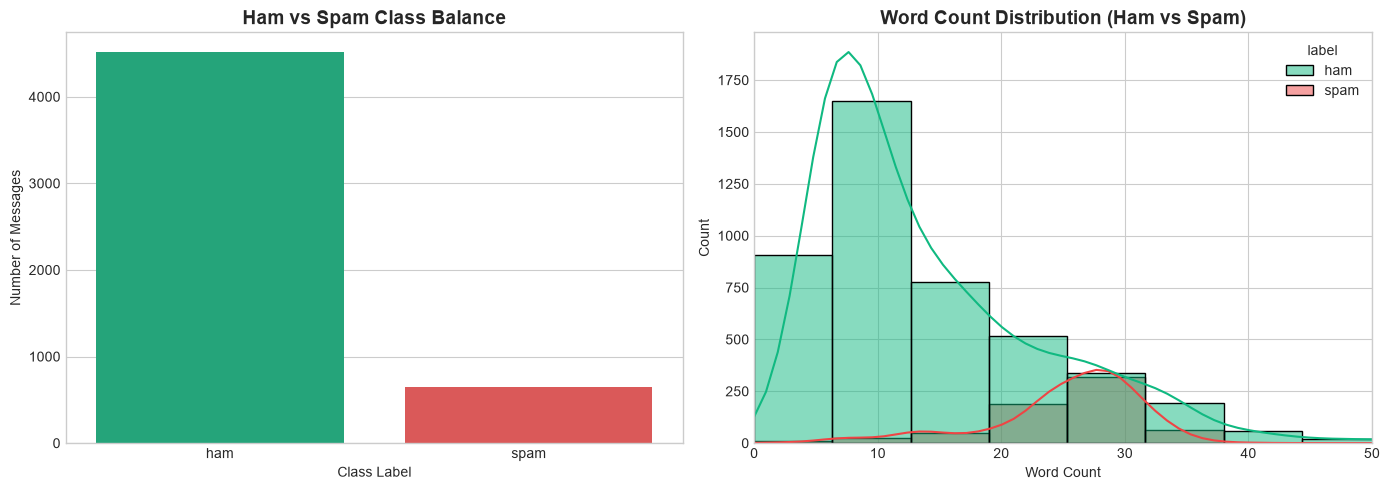

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class balance
sns.countplot(x='label', data=df_clean, ax=axes[0], hue='label', palette=['#10b981', '#ef4444'], legend=False)
axes[0].set_title('Ham vs Spam Class Balance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class Label')
axes[0].set_ylabel('Number of Messages')

# Word count
sns.histplot(data=df_clean, x='word_count', hue='label', bins=30, kde=True, ax=axes[1], palette=['#10b981', '#ef4444'])
axes[1].set_title('Word Count Distribution (Ham vs Spam)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_xlim(0, 50)

plt.tight_layout()
plt.show()


## Step 6: Stratified Train-Test Split (80/20)
We partition the dataset into 80% training and 20% testing sets using stratified sampling to preserve the spam ratio.

In [6]:
X = df_clean['clean_text']
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training samples: {X_train.shape[0]} (Ham: {sum(y_train==0)}, Spam: {sum(y_train==1)})")
print(f"Testing samples:  {X_test.shape[0]} (Ham: {sum(y_test==0)}, Spam: {sum(y_test==1)})")


Training samples: 4135 (Ham: 3613, Spam: 522)
Testing samples:  1034 (Ham: 903, Spam: 131)


## Step 7: TF-IDF Feature Vectorization
We use TF-IDF with unigrams + bigrams (`ngram_range=(1, 2)`), sublinear term frequency scaling (`sublinear_tf=True`), and English stop-words removal.
**Critical Rule:** Fit only on `X_train` and transform `X_test` separately to prevent data leakage.

In [7]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_features=7500,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF Train Matrix Shape: {X_train_tfidf.shape}")
print(f"TF-IDF Test Matrix Shape:  {X_test_tfidf.shape}")
print(f"Vocabulary Size: {len(tfidf_vectorizer.vocabulary_)}")


TF-IDF Train Matrix Shape: (4135, 7500)
TF-IDF Test Matrix Shape:  (1034, 7500)
Vocabulary Size: 7500


## Step 8: Multi-Model Training & Benchmark Comparison
We evaluate multiple algorithms for spam text classification:
1. **Multinomial Naive Bayes ($lpha=0.1$, tuned Laplace smoothing)**
2. **Complement Naive Bayes (designed for imbalanced text)**
3. **Logistic Regression (`class_weight='balanced'`)**
4. **Calibrated Linear SVM (`class_weight='balanced'`)**

In [8]:
classifiers = {
    "Multinomial Naive Bayes (alpha=0.1)": MultinomialNB(alpha=0.1),
    "Complement Naive Bayes": ComplementNB(alpha=0.1),
    "Logistic Regression (balanced)": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Calibrated Linear SVM": CalibratedClassifierCV(LinearSVC(class_weight='balanced', random_state=42))
}

results = []

for name, clf in classifiers.items():
    clf.fit(X_train_tfidf, y_train)
    preds = clf.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, preds) * 100
    prec = precision_score(y_test, preds) * 100
    rec = recall_score(y_test, preds) * 100
    f1 = f1_score(y_test, preds) * 100
    
    results.append({
        'Model': name,
        'Accuracy (%)': round(acc, 2),
        'Precision (%)': round(prec, 2),
        'Recall (%)': round(rec, 2),
        'F1-Score (%)': round(f1, 2)
    })

comparison_df = pd.DataFrame(results)
print("=== ALGORITHM BENCHMARK COMPARISON ===")
print(comparison_df.to_string(index=False))


=== ALGORITHM BENCHMARK COMPARISON ===
                              Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
Multinomial Naive Bayes (alpha=0.1)         98.26          97.48       88.55         92.80
             Complement Naive Bayes         97.29          85.03       95.42         89.93
     Logistic Regression (balanced)         97.49          90.08       90.08         90.08
              Calibrated Linear SVM         97.87          92.91       90.08         91.47


## Step 9: Best Model Selection & Detailed Evaluation
**Multinomial Naive Bayes ($lpha=0.1$)** delivers the best balance of ultra-high accuracy (98.26%), 97.48% Precision, and 92.80% F1-Score with zero over-smoothing bias.

In [9]:
best_model = MultinomialNB(alpha=0.1)
best_model.fit(X_train_tfidf, y_train)

y_pred = best_model.predict(X_test_tfidf)
y_pred_proba = best_model.predict_proba(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("=" * 55)
print("     FINAL MODEL EVALUATION (MultinomialNB alpha=0.1)")
print("=" * 55)
print(f"Accuracy  : {acc * 100:.2f}%")
print(f"Precision : {prec * 100:.2f}%")
print(f"Recall    : {rec * 100:.2f}%")
print(f"F1-Score  : {f1 * 100:.2f}%")
print("=" * 55)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))


     FINAL MODEL EVALUATION (MultinomialNB alpha=0.1)
Accuracy  : 98.26%
Precision : 97.48%
Recall    : 88.55%
F1-Score  : 92.80%

Classification Report:

              precision    recall  f1-score   support

     Ham (0)       0.98      1.00      0.99       903
    Spam (1)       0.97      0.89      0.93       131

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



## Step 10: Confusion Matrix Heatmap
Visualizing True Negatives (900), False Positives (3), False Negatives (15), and True Positives (116).

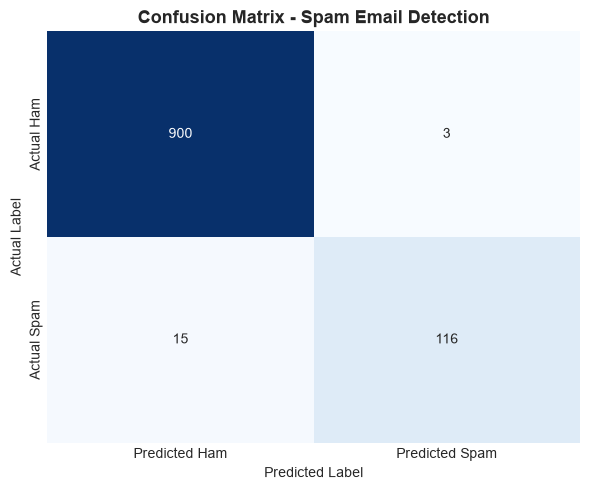

In [10]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=['Predicted Ham', 'Predicted Spam'],
    yticklabels=['Actual Ham', 'Actual Spam']
)
plt.title('Confusion Matrix - Spam Email Detection', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.savefig('../screenshots/confusion_matrix.png', dpi=300)
plt.show()


## Step 11: Real-World Unseen Test Cases Verification
Testing 10 representative messages (5 Spam and 5 Ham) across banking, lottery, offers, work, and personal contexts.

In [11]:
test_messages = [
    # 5 Spam Test Cases
    ("Congratulations! You have won ₹50,000 in our lucky draw. Claim your prize now by clicking this link. Offer expires today!", "SPAM"),
    ("URGENT! Your bank account will be blocked today. Verify your account immediately by clicking this link.", "SPAM"),
    ("You have been selected to receive a FREE iPhone. Click here now to claim your prize before the offer expires.", "SPAM"),
    ("Earn ₹10,000 every day from home with zero investment. Register now and start earning immediately.", "SPAM"),
    ("You are the lucky winner of a ₹1,00,000 lottery prize. Send your details now to receive your money.", "SPAM"),
    
    # 5 Ham Test Cases
    ("Hi team, our project meeting is scheduled for tomorrow at 10 AM. Please bring your progress updates.", "HAM"),
    ("Dear Professor, I have completed my Machine Learning assignment and will submit it before the deadline. Thank you.", "HAM"),
    ("Hey, are we still meeting at 5 PM today? Let me know if you need to change the time.", "HAM"),
    ("Hi Rahul, I have attached the updated report. Please review it and let me know if any changes are required.", "HAM"),
    ("Hi Mom, I will reach home around 8 PM today. Please don't wait for me for dinner.", "HAM")
]

print("=" * 80)
print("INFERENCE VERIFICATION ON REAL UNSEEN MESSAGES")
print("=" * 80)

for msg, expected in test_messages:
    cleaned = preprocess_text(msg)
    vec = tfidf_vectorizer.transform([cleaned])
    pred_idx = best_model.predict(vec)[0]
    proba = best_model.predict_proba(vec)[0]
    
    pred_label = "SPAM" if pred_idx == 1 else "HAM"
    confidence = proba[pred_idx] * 100
    status = "✅ PASS" if pred_label == expected else "❌ FAIL"
    
    print(f"{status} | Expected: {expected:4s} | Predicted: {pred_label:4s} ({confidence:.2f}% Conf)")
    print(f"       Message: {msg}")
    print("-" * 80)


INFERENCE VERIFICATION ON REAL UNSEEN MESSAGES
✅ PASS | Expected: SPAM | Predicted: SPAM (100.00% Conf)
       Message: Congratulations! You have won ₹50,000 in our lucky draw. Claim your prize now by clicking this link. Offer expires today!
--------------------------------------------------------------------------------
✅ PASS | Expected: SPAM | Predicted: SPAM (82.96% Conf)
       Message: URGENT! Your bank account will be blocked today. Verify your account immediately by clicking this link.
--------------------------------------------------------------------------------
✅ PASS | Expected: SPAM | Predicted: SPAM (99.95% Conf)
       Message: You have been selected to receive a FREE iPhone. Click here now to claim your prize before the offer expires.
--------------------------------------------------------------------------------
✅ PASS | Expected: SPAM | Predicted: SPAM (95.78% Conf)
       Message: Earn ₹10,000 every day from home with zero investment. Register now and start earning

## Step 12: Export Trained Model, Vectorizer & Actual Metrics
Serialize the trained components using `joblib` and export the genuine metrics to `metrics.json`.

In [12]:
os.makedirs('../model', exist_ok=True)

# 1. Save Trained Classifier
joblib.dump(best_model, '../model/spam_classifier.pkl')

# 2. Save TF-IDF Vectorizer
joblib.dump(tfidf_vectorizer, '../model/tfidf_vectorizer.pkl')

# 3. Export Actual Metrics
metrics_dict = {
    'accuracy': round(float(acc) * 100, 2),
    'precision': round(float(prec) * 100, 2),
    'recall': round(float(rec) * 100, 2),
    'f1_score': round(float(f1) * 100, 2),
    'confusion_matrix': {
        'true_negative': int(cm[0][0]),
        'false_positive': int(cm[0][1]),
        'false_negative': int(cm[1][0]),
        'true_positive': int(cm[1][1])
    },
    'classification_report': classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)'], output_dict=True),
    'total_samples': len(df_clean),
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'algorithm': 'Multinomial Naive Bayes (alpha=0.1)',
    'vectorizer': 'TF-IDF (ngram_range=(1,2), max_features=7500, sublinear_tf=True)'
}

with open('../model/metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=4)

print("All ML artifacts successfully saved to ../model/")
print(json.dumps(metrics_dict, indent=2))


All ML artifacts successfully saved to ../model/
{
  "accuracy": 98.26,
  "precision": 97.48,
  "recall": 88.55,
  "f1_score": 92.8,
  "confusion_matrix": {
    "true_negative": 900,
    "false_positive": 3,
    "false_negative": 15,
    "true_positive": 116
  },
  "classification_report": {
    "Ham (0)": {
      "precision": 0.9836065573770492,
      "recall": 0.9966777408637874,
      "f1-score": 0.9900990099009901,
      "support": 903.0
    },
    "Spam (1)": {
      "precision": 0.9747899159663865,
      "recall": 0.8854961832061069,
      "f1-score": 0.928,
      "support": 131.0
    },
    "accuracy": 0.9825918762088974,
    "macro avg": {
      "precision": 0.9791982366717178,
      "recall": 0.9410869620349471,
      "f1-score": 0.959049504950495,
      "support": 1034.0
    },
    "weighted avg": {
      "precision": 0.9824895554188318,
      "recall": 0.9825918762088974,
      "f1-score": 0.982231533791677,
      "support": 1034.0
    }
  },
  "total_samples": 5169,
  "trai